In [1]:
#ignorning the warnings
import warnings
warnings.filterwarnings(action='ignore')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#for creating more complex subplots instead of using basic subplot function
import matplotlib.gridspec as gridspec
# allows you to define a colormap using a list of color specifications.
from matplotlib.colors import LinearSegmentedColormap
import plotly.graph_objects as go
from matplotlib import colors as mcolors
#this only gives basic stats and linear relation between 2 variables and used when you dont need ML model
from scipy.stats import linregress
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans
# used to create formatted tables from various data structures
from tabulate import tabulate
from collections import Counter
# Matplotlib plots directly in the notebook, rather than in a separate window or file.
%matplotlib inline
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

In [2]:
df=pd.read_csv('data.csv',encoding="ISO-8859-1")


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,10/31/2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.describe()


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
df.describe(include='object').T


,count,unique,top,freq
InvoiceNo,541909,25900,573585,1114
StockCode,541909,4070,85123A,2313
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369
InvoiceDate,541909,23260,10/31/2011 14:41,1114
Country,541909,38,United Kingdom,495478


In [8]:
df.isnull().sum()


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [9]:
missindescrip=df['Description'].isnull().sum()/df.shape[0]*100
missincustomer=df['CustomerID'].isnull().sum()/df.shape[0]*100
print(missindescrip)
missincustomer

0.2683107311375157


np.float64(24.926694334288598)

In [10]:
#dropping all the rowns which have Nan values
df.dropna(subset=['Description','CustomerID'],axis=0,how='any',inplace=True)
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [11]:
df.isnull().sum()


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [12]:
duplicate_rows=df.duplicated(keep=False)
df[duplicate_rows].sort_values(by='InvoiceNo')


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
...,...,...,...,...,...,...,...,...
440149,C574510,22360,GLASS JAR ENGLISH CONFECTIONERY,-1,11/4/2011 13:25,2.95,15110.0,United Kingdom
461407,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,11/13/2011 11:38,0.55,17838.0,United Kingdom
461408,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,11/13/2011 11:38,0.55,17838.0,United Kingdom
529981,C580764,22667,RECIPE BOX RETROSPOT,-12,12/6/2011 10:38,2.95,14562.0,United Kingdom


In [13]:
df.drop_duplicates(inplace=True)
df.shape[0]

401604

In [14]:
df['Transaction_Status'] = np.where(df['InvoiceNo'].astype(str).str.startswith('C'), 'Cancelled', 'Completed')

canceltrans = df[df['Transaction_Status'] == 'Cancelled']
canceltrans.describe().drop('CustomerID', axis=1)

,Quantity,UnitPrice
count,8872.000000,8872.000000
mean,-30.774910,18.899512
std,1172.249902,445.190864
min,-80995.000000,0.010000
25%,-6.000000,1.450000
50%,-2.000000,2.950000
75%,-1.000000,4.950000
max,-1.000000,38970.000000


In [15]:
canceltrans.shape[0]/df.shape[0]*100

2.209141343213713

<Axes: title={'center': 'Bar Chart Example'}, xlabel='Index', ylabel='Values'>

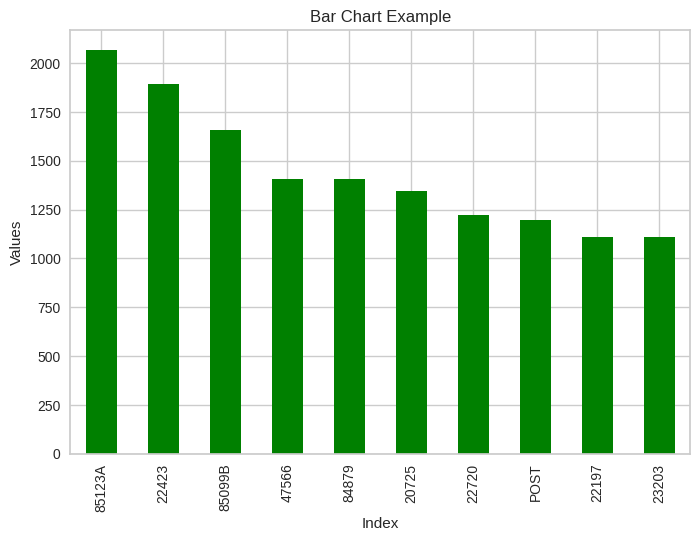

In [16]:
#top 10 popular stocks
top10stock = df['StockCode'].value_counts().head(10)
top10stock.plot(
    kind='bar',    # Change plot type to bar chart
    title='Bar Chart Example',
    xlabel='Index',
    ylabel='Values',
    color='green',  # Change bar color
    grid=True       # Display grid
)

In [17]:
#poCategoricalst in the above graph can just be postal charges to avoide those
unique_stock_code=df['StockCode'].unique()
unique_stock_code

array(['85123A', '71053', '84406B', ..., '90214Z', '90089', '23843'],
      dtype=object)

In [18]:
pd.Series(unique_stock_code).apply(lambda x:sum(c.isdigit()for c in x)).value_counts()


,count
5,3676
0,7
1,1


In [19]:
type(unique_stock_code)


numpy.ndarray

In [20]:
anomalous_stock_code=[code for code in unique_stock_code if sum( c.isdigit() for c in code) in (0,1)]

In [21]:
anomalous_stock_code


['POST', 'D', 'C2', 'M', 'BANK CHARGES', 'PADS', 'DOT', 'CRUK']

In [22]:
df=df[~df['StockCode'].isin(anomalous_stock_code)]

In [23]:
#removed the anomalous stock code
df.shape

(399689, 9)

In [24]:
df['Description'].value_counts().head(50)


,count
Description,
WHITE HANGING HEART T-LIGHT HOLDER,2058
REGENCY CAKESTAND 3 TIER,1894
JUMBO BAG RED RETROSPOT,1659
PARTY BUNTING,1409
ASSORTED COLOUR BIRD ORNAMENT,1405
LUNCH BAG RED RETROSPOT,1345
SET OF 3 CAKE TINS PANTRY DESIGN,1224
LUNCH BAG BLACK SKULL.,1099
PACK OF 72 RETROSPOT CAKE CASES,1062


In [25]:
lower_discription=df['Description'].unique()
lower_discription=[d for d in lower_discription if any(x.islower()for x in d )  ]
lower_discription

['BAG 500g SWIRLY MARBLES',
 'POLYESTER FILLER PAD 45x45cm',
 'POLYESTER FILLER PAD 45x30cm',
 'POLYESTER FILLER PAD 40x40cm',
 'FRENCH BLUE METAL DOOR SIGN No',
 'BAG 250g SWIRLY MARBLES',
 'BAG 125g SWIRLY MARBLES',
 '3 TRADITIONAl BISCUIT CUTTERS  SET',
 'NUMBER TILE COTTAGE GARDEN No',
 'FOLK ART GREETING CARD,pack/12',
 'ESSENTIAL BALM 3.5g TIN IN ENVELOPE',
 'POLYESTER FILLER PAD 65CMx65CM',
 'NUMBER TILE VINTAGE FONT No ',
 'POLYESTER FILLER PAD 30CMx30CM',
 'POLYESTER FILLER PAD 60x40cm',
 'FLOWERS HANDBAG blue and orange',
 'Next Day Carriage',
 'THE KING GIFT BAG 25x24x12cm',
 'High Resolution Image']

In [26]:
#now drop unrelated descriptions
df=df[~df['Description'].isin(['Next Day Carriage','High Resolution Image'])]

In [27]:
df.isin(['Next Day Carriage','High Resolution Image']).sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
Transaction_Status,0


In [28]:
#make all descriptions either upper or lower case.
df['Description'] = df['Description'].str.upper()
df['Description']

,Description
0,WHITE HANGING HEART T-LIGHT HOLDER
1,WHITE METAL LANTERN
2,CREAM CUPID HEARTS COAT HANGER
3,KNITTED UNION FLAG HOT WATER BOTTLE
4,RED WOOLLY HOTTIE WHITE HEART.
...,...
541904,PACK OF 20 SPACEBOY NAPKINS
541905,CHILDREN'S APRON DOLLY GIRL
541906,CHILDRENS CUTLERY DOLLY GIRL
541907,CHILDRENS CUTLERY CIRCUS PARADE


In [29]:
df['UnitPrice'].describe()


,UnitPrice
count,399606.000000
mean,2.904957
std,4.448796
min,0.000000
25%,1.250000
50%,1.950000
75%,3.750000
max,649.500000


In [30]:
#minimum is given 0 so mean free,it might be a error or something else
sum(df['UnitPrice']==0)
#33 unitprices are given 0

33

In [31]:
df=df[df['UnitPrice']>0]


In [32]:
df['UnitPrice'].describe()


,UnitPrice
count,399573.000000
mean,2.905197
std,4.448902
min,0.030000
25%,1.250000
50%,1.950000
75%,3.750000
max,649.500000


In [33]:
#now after all this data cleaning there are many missing indexes so reset the index for a fresh index


df.reset_index( drop=True,inplace=True)
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Transaction_Status
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,Completed
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,Completed
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,Completed
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,Completed
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,Completed
...,...,...,...,...,...,...,...,...,...
399568,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France,Completed
399569,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France,Completed
399570,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France,Completed
399571,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France,Completed


In [34]:
#first lets convert the invoice data to datatime variable to be able to perform operation on it
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df['InvoiceDate']

,InvoiceDate
0,2010-12-01 08:26:00
1,2010-12-01 08:26:00
2,2010-12-01 08:26:00
3,2010-12-01 08:26:00
4,2010-12-01 08:26:00
...,...
399568,2011-12-09 12:50:00
399569,2011-12-09 12:50:00
399570,2011-12-09 12:50:00
399571,2011-12-09 12:50:00


In [35]:
df['InvoiceDay'] = df['InvoiceDate'].dt.date
customer_data=df.groupby(['CustomerID'])['InvoiceDay'].max().reset_index()
#created a new dataframe for customer data and from on every cutomer related feature will nbe added
type(customer_data)

pandas.core.frame.DataFrame

In [36]:
customer_data['InvoiceDay']=pd.to_datetime(customer_data['InvoiceDay'])
most_recent_date=pd.to_datetime(customer_data['InvoiceDay'].max())
customer_data['day_since_last_purchase']=(most_recent_date-customer_data['InvoiceDay']).dt.days

customer_data.drop(['InvoiceDay'],axis=1,inplace=True)
customer_data

,CustomerID,day_since_last_purchase
0,12346.0,325
1,12347.0,2
2,12348.0,75
3,12349.0,18
4,12350.0,310
...,...,...
4357,18280.0,277
4358,18281.0,180
4359,18282.0,7
4360,18283.0,3


In [37]:
#with the code below we know the no of trasactions by a customer
total_trasactions=df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()

total_products=df.groupby('CustomerID')['Quantity'].sum().reset_index()

customer_data=customer_data.merge(total_trasactions,on='CustomerID').merge(total_products,on='CustomerID')
customer_data=customer_data.rename({'InvoiceNo':'Total_Transactions','Quantity':'Total_Products_Purchased'},axis=1)

In [38]:
customer_data


,CustomerID,day_since_last_purchase,Total_Transactions,Total_Products_Purchased
0,12346.0,325,2,0
1,12347.0,2,7,2458
2,12348.0,75,4,2332
3,12349.0,18,1,630
4,12350.0,310,1,196
...,...,...,...,...
4357,18280.0,277,1,45
4358,18281.0,180,1,54
4359,18282.0,7,3,98
4360,18283.0,3,16,1355


In [39]:
df['total_spend']=df['UnitPrice']*df['Quantity']

total_spend=df.groupby('CustomerID')['total_spend'].sum().reset_index()

customer_data=customer_data.merge(total_spend,on='CustomerID')
customer_data['Average_Transaction_Value']=customer_data['total_spend'] / customer_data['Total_Transactions']

In [40]:
customer_data


,CustomerID,day_since_last_purchase,Total_Transactions,Total_Products_Purchased,total_spend,Average_Transaction_Value
0,12346.0,325,2,0,0.00,0.000000
1,12347.0,2,7,2458,4310.00,615.714286
2,12348.0,75,4,2332,1437.24,359.310000
3,12349.0,18,1,630,1457.55,1457.550000
4,12350.0,310,1,196,294.40,294.400000
...,...,...,...,...,...,...
4357,18280.0,277,1,45,180.60,180.600000
4358,18281.0,180,1,54,80.82,80.820000
4359,18282.0,7,3,98,176.60,58.866667
4360,18283.0,3,16,1355,2039.58,127.473750


In [41]:
unique_products_purchased=df.groupby('CustomerID')['StockCode'].nunique()
customer_data=customer_data.merge(unique_products_purchased,on='CustomerID')
customer_data=customer_data.rename(columns={'StockCode':'Unique_Products_Purchased'})
customer_data

,CustomerID,day_since_last_purchase,Total_Transactions,Total_Products_Purchased,total_spend,Average_Transaction_Value,Unique_Products_Purchased
0,12346.0,325,2,0,0.00,0.000000,1
1,12347.0,2,7,2458,4310.00,615.714286,103
2,12348.0,75,4,2332,1437.24,359.310000,21
3,12349.0,18,1,630,1457.55,1457.550000,72
4,12350.0,310,1,196,294.40,294.400000,16
...,...,...,...,...,...,...,...
4357,18280.0,277,1,45,180.60,180.600000,10
4358,18281.0,180,1,54,80.82,80.820000,7
4359,18282.0,7,3,98,176.60,58.866667,12
4360,18283.0,3,16,1355,2039.58,127.473750,262


In [42]:
df['Day_Of_Week']=df['InvoiceDate'].dt.dayofweek
df['Hour']=df['InvoiceDate'].dt.hour

In [43]:
#average days between purchases by a customer
days_between_purchases = df.groupby('CustomerID')['InvoiceDay'].apply(lambda x: (x.diff().dropna()).apply(lambda y: y.days))
average_days_between_purchases=days_between_purchases.groupby('CustomerID').mean().reset_index()
average_days_between_purchases.rename({'InvoiceDay': 'Average_Days_Between_Purchases'},axis=1,inplace=True)

In [44]:
#favorite shopping day of the week
favorite_shopping_day = df.groupby(['CustomerID', 'Day_Of_Week']).size().reset_index(name='Count')
favorite_shopping_day = favorite_shopping_day.loc[favorite_shopping_day.groupby('CustomerID')['Count'].idxmax()][['CustomerID', 'Day_Of_Week']]
favorite_shopping_day

,CustomerID,Day_Of_Week
0,12346.0,1
2,12347.0,1
6,12348.0,3
8,12349.0,0
9,12350.0,2
...,...,...
10599,18280.0,0
10600,18281.0,6
10602,18282.0,4
10606,18283.0,3


In [45]:
#favorite hour to shop
favorite_shopping_hour = df.groupby(['CustomerID', 'Hour']).size().reset_index(name='Count')
favorite_shopping_hour = favorite_shopping_hour.loc[favorite_shopping_hour.groupby('CustomerID')['Count'].idxmax()][['CustomerID', 'Hour']]
favorite_shopping_hour

,CustomerID,Hour
0,12346.0,10
5,12347.0,14
9,12348.0,19
10,12349.0,9
11,12350.0,16
...,...,...
12554,18280.0,9
12555,18281.0,10
12557,18282.0,13
12563,18283.0,14


In [46]:
#merging all the data frames with main dataframe
temp=pd.merge(pd.merge(favorite_shopping_day,favorite_shopping_hour,on='CustomerID'),average_days_between_purchases, on='CustomerID')
customer_data=pd.merge(customer_data,temp,on='CustomerID')

In [47]:
customer_data


,CustomerID,day_since_last_purchase,Total_Transactions,Total_Products_Purchased,total_spend,Average_Transaction_Value,Unique_Products_Purchased,Day_Of_Week,Hour,Average_Days_Between_Purchases
0,12346.0,325,2,0,0.00,0.000000,1,1,10,0.000000
1,12347.0,2,7,2458,4310.00,615.714286,103,1,14,2.016575
2,12348.0,75,4,2332,1437.24,359.310000,21,3,19,10.884615
3,12349.0,18,1,630,1457.55,1457.550000,72,0,9,0.000000
4,12350.0,310,1,196,294.40,294.400000,16,2,16,0.000000
...,...,...,...,...,...,...,...,...,...,...
4277,18280.0,277,1,45,180.60,180.600000,10,0,9,0.000000
4278,18281.0,180,1,54,80.82,80.820000,7,6,10,0.000000
4279,18282.0,7,3,98,176.60,58.866667,12,4,13,9.916667
4280,18283.0,3,16,1355,2039.58,127.473750,262,3,14,0.465181


In [48]:
df['Country'].value_counts(normalize=True)

,proportion
Country,
United Kingdom,0.890971
Germany,0.022722
France,0.020402
EIRE,0.018440
Spain,0.006162
Netherlands,0.005821
Belgium,0.004933
Switzerland,0.004612
Portugal,0.003571


In [49]:
# Group by CustomerID and Country to get the number of transactions per country for each customer
customer_country = df.groupby(['CustomerID', 'Country']).size().reset_index(name='Number_of_Transactions')

# Get the country with the maximum number of transactions for each customer (in case a customer has transactions from multiple countries)
customer_main_country = customer_country.sort_values('Number_of_Transactions', ascending=False).drop_duplicates('CustomerID')

# Create a binary column indicating whether the customer is from the UK or not
customer_main_country['Is_UK'] = customer_main_country['Country'].apply(lambda x: 1 if x == 'United Kingdom' else 0)

# Merge this data with our customer_data dataframe
customer_data = pd.merge(customer_data, customer_main_country[['CustomerID', 'Is_UK']], on='CustomerID', how='left')

In [50]:
customer_data['Is_UK'].value_counts()


,count
Is_UK,
1,3866
0,416


In [51]:
total_transactions = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
cancelled_transactions = df[df['Transaction_Status'] == 'Cancelled']

In [52]:
#calculate the cancelled transactions for each coustomer
cancellation_frequency = cancelled_transactions.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
cancellation_frequency.rename(columns={'InvoiceNo': 'Cancellation_Frequency'}, inplace=True)

In [53]:
customer_data = pd.merge(customer_data, cancellation_frequency, on='CustomerID', how='left')
#for customer who hasnt had any cancelled transactions
customer_data['Cancellation_Frequency'].fillna(0, inplace=True)
customer_data['Cancellation_Rate'] = customer_data['Cancellation_Frequency'] / total_transactions['InvoiceNo']

In [54]:
customer_data.head()


,CustomerID,day_since_last_purchase,Total_Transactions,Total_Products_Purchased,total_spend,Average_Transaction_Value,Unique_Products_Purchased,Day_Of_Week,Hour,Average_Days_Between_Purchases,Is_UK,Cancellation_Frequency,Cancellation_Rate
0,12346.0,325,2,0,0.00,0.000000,1,1,10,0.000000,1,1.0,0.5
1,12347.0,2,7,2458,4310.00,615.714286,103,1,14,2.016575,0,0.0,0.0
2,12348.0,75,4,2332,1437.24,359.310000,21,3,19,10.884615,0,0.0,0.0
3,12349.0,18,1,630,1457.55,1457.550000,72,0,9,0.000000,0,0.0,0.0
4,12350.0,310,1,196,294.40,294.400000,16,2,16,0.000000,0,0.0,0.0


In [55]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month

# Calculate monthly spending for each customer
monthly_spending = df.groupby(['CustomerID', 'Year', 'Month'])['total_spend'].sum().reset_index()

In [56]:
#calculating the mean spending in a month and stansard deviation in that spending.
seasonal_buying_patterns = monthly_spending.groupby('CustomerID')['total_spend'].agg(['mean', 'std']).reset_index()
seasonal_buying_patterns.rename(columns={'mean': 'Monthly_Spending_Mean', 'std': 'Monthly_Spending_Std'}, inplace=True)

In [57]:
#cutomers with a single trasaction has nan std,so replace it with 0
seasonal_buying_patterns['Monthly_Spending_Std'].fillna(0, inplace=True)

In [58]:
# Calculate Trends in Spending
# We are using the slope of the linear trend line fitted to the customer's spending over time as an indicator of spending trends
def calculate_trend(spend_data):
    # If there are more than one data points, we calculate the trend using linear regression
    if len(spend_data) > 1:
        x = np.arange(len(spend_data))
        slope, intercept,_,_,_ = linregress(x, spend_data)
        return slope
    # If there is only one data point, no trend can be calculated, hence we return 0
    else:
        return 0

In [59]:
# Apply the calculate_trend function to find the spending trend for each customer
spending_trends = monthly_spending.groupby('CustomerID')['total_spend'].apply(calculate_trend).reset_index()
spending_trends.rename(columns={'total_spend': 'Spending_Trend'}, inplace=True)
# Merge the new features into the customer_data dataframe
customer_data = pd.merge(customer_data, seasonal_buying_patterns, on='CustomerID')
customer_data = pd.merge(customer_data, spending_trends, on='CustomerID')

In [60]:
customer_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4282 entries, 0 to 4281
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   CustomerID                      4282 non-null   float64
 1   day_since_last_purchase         4282 non-null   int64  
 2   Total_Transactions              4282 non-null   int64  
 3   Total_Products_Purchased        4282 non-null   int64  
 4   total_spend                     4282 non-null   float64
 5   Average_Transaction_Value       4282 non-null   float64
 6   Unique_Products_Purchased       4282 non-null   int64  
 7   Day_Of_Week                     4282 non-null   int32  
 8   Hour                            4282 non-null   int32  
 9   Average_Days_Between_Purchases  4282 non-null   float64
 10  Is_UK                           4282 non-null   int64  
 11  Cancellation_Frequency          4282 non-null   float64
 12  Cancellation_Rate               42

In [61]:
# Changing the data type of 'CustomerID' to string as it is a unique identifier and not used in mathematical operations
customer_data['CustomerID'] = customer_data['CustomerID'].astype(str)

# Convert data types of columns to optimal types
customer_data = customer_data.convert_dtypes()

Text(0, 0.5, 'Is Outlier')

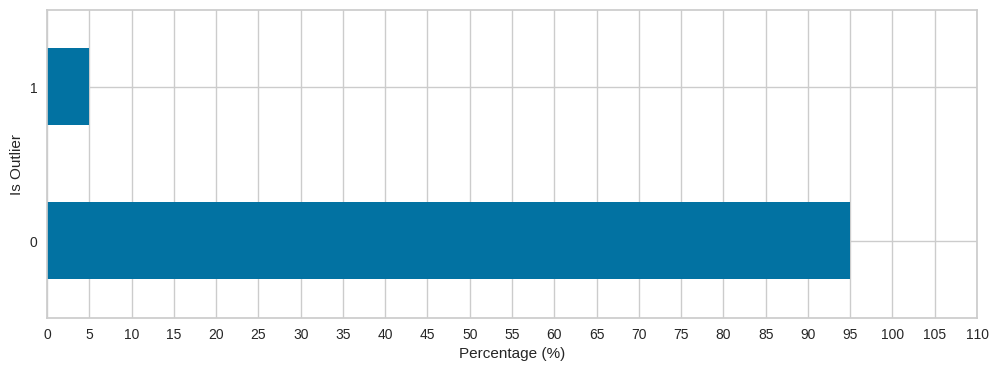

In [62]:
# Initializing the IsolationForest model with a contamination parameter of 0.05
model = IsolationForest(contamination=0.05, random_state=0)

# Fitting the model on our dataset (converting DataFrame to NumPy to avoid warning)
customer_data['Outlier_Scores'] = model.fit_predict(customer_data.iloc[:, 1:].to_numpy())

# Creating a new column to identify outliers (1 for inliers and -1 for outliers)
customer_data['Is_Outlier'] = [1 if x == -1 else 0 for x in customer_data['Outlier_Scores']]
#now lets visualize the inliners and ouliners percentage
outlier_percentage = customer_data['Is_Outlier'].value_counts(normalize=True) * 100
# Plotting the percentage of inliers and outliers
plt.figure(figsize=(12, 4))
outlier_percentage.plot(kind='barh')
plt.xticks(ticks=np.arange(0, 115, 5))
plt.xlabel('Percentage (%)')
plt.ylabel('Is Outlier')

In [63]:
# Separate the outliers for analysis
outliers_data = customer_data[customer_data['Is_Outlier'] == 1]

# Remove the outliers from the main dataset
customer_data_cleaned = customer_data[customer_data['Is_Outlier'] == 0]

# Drop the 'Outlier_Scores' and 'Is_Outlier' columns
customer_data_cleaned = customer_data_cleaned.drop(columns=['Outlier_Scores', 'Is_Outlier'])

# Reset the index of the cleaned data
customer_data_cleaned.reset_index(drop=True, inplace=True)
customer_data_cleaned.shape

(4067, 16)

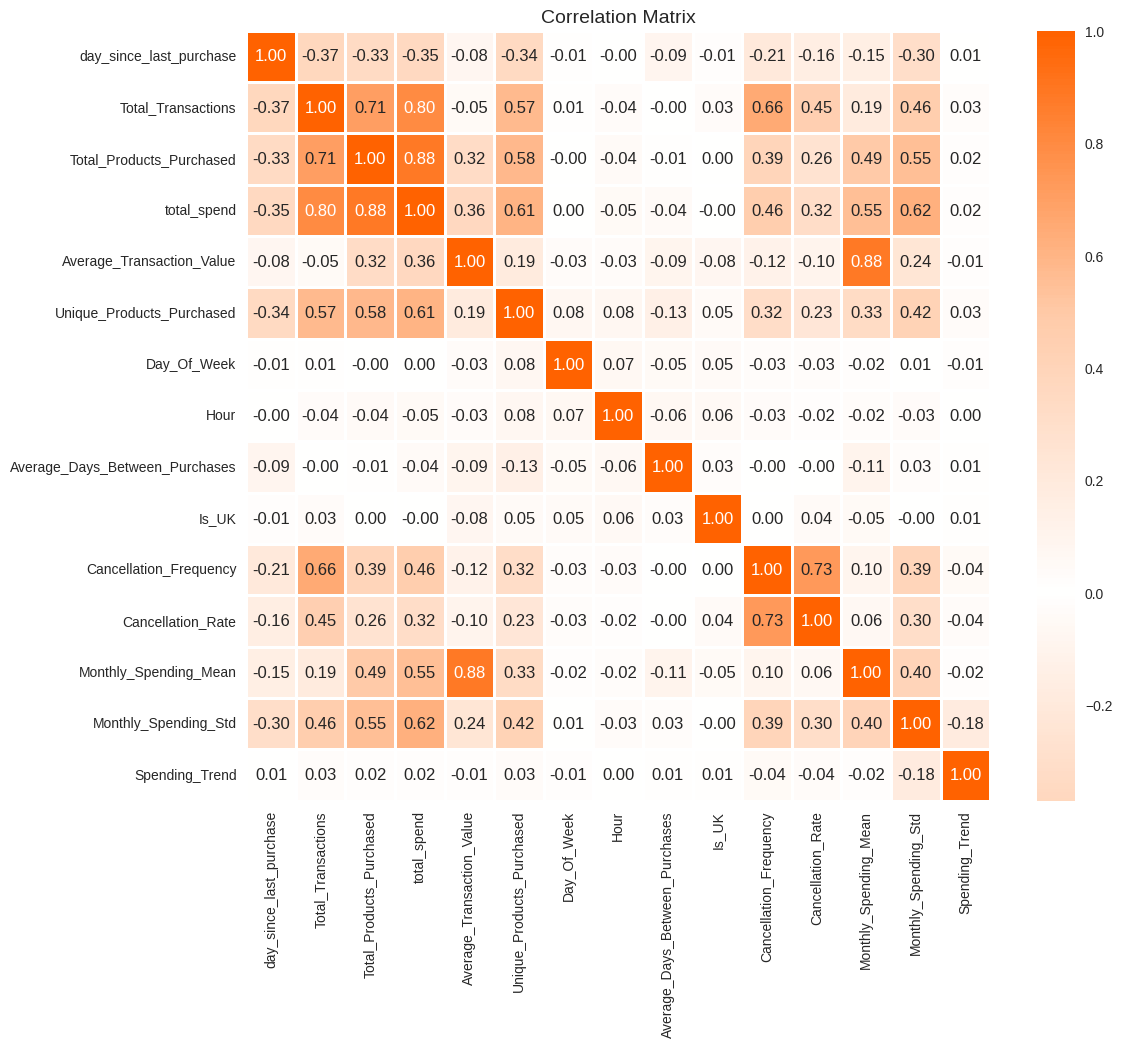

In [64]:
colors = ['#ff6200', '#ffcaa8', 'white', '#ffcaa8', '#ff6200']
# Define a custom colormap
my_cmap = LinearSegmentedColormap.from_list('custom_map', colors, N=256)
corr = customer_data_cleaned.drop(columns=['CustomerID']).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr,cmap=my_cmap, annot=True, center=0, fmt='.2f', linewidths=2)
plt.title('Correlation Matrix', fontsize=14)
plt.show()

In [65]:
# Initialize the StandardScaler
scaler = StandardScaler()

# List of columns that don't need to be scaled
columns_to_exclude = ['CustomerID', 'Is_UK', 'Day_Of_Week']

# List of columns that need to be scaled
columns_to_scale = customer_data_cleaned.columns.difference(columns_to_exclude)

# Copy the cleaned dataset
customer_data_scaled = customer_data_cleaned.copy()

# Applying the scaler to the necessary columns in the dataset
customer_data_scaled[columns_to_scale] = scaler.fit_transform(customer_data_scaled[columns_to_scale])

# Display the first few rows of the scaled data
customer_data_scaled.head()

,CustomerID,day_since_last_purchase,Total_Transactions,Total_Products_Purchased,total_spend,Average_Transaction_Value,Unique_Products_Purchased,Day_Of_Week,Hour,Average_Days_Between_Purchases,Is_UK,Cancellation_Frequency,Cancellation_Rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,12346.0,2.347204,-0.474754,-0.761864,-0.814708,-1.334083,-0.896574,1,-1.089647,-0.301104,1,0.392245,0.398937,-1.346825,-0.725881,0.091811
1,12347.0,-0.903164,0.672498,2.018300,2.359182,1.572434,0.788415,1,0.643476,-0.127262,0,-0.539022,-0.431735,1.017816,1.299244,0.118328
2,12348.0,-0.168561,-0.015853,1.875785,0.243678,0.362062,-0.566184,3,2.809879,0.637222,0,-0.539022,-0.431735,0.033100,0.484641,-0.504516
3,12350.0,2.196258,-0.704205,-0.540175,-0.597911,0.055650,-0.648781,2,1.510037,-0.301104,0,-0.539022,-0.431735,-0.216186,-0.725881,0.091811
4,12352.0,-0.561020,0.901949,-0.238180,0.117142,-0.587403,0.028518,1,0.643476,-0.031059,0,0.392245,-0.224067,-0.131878,0.073911,0.147085


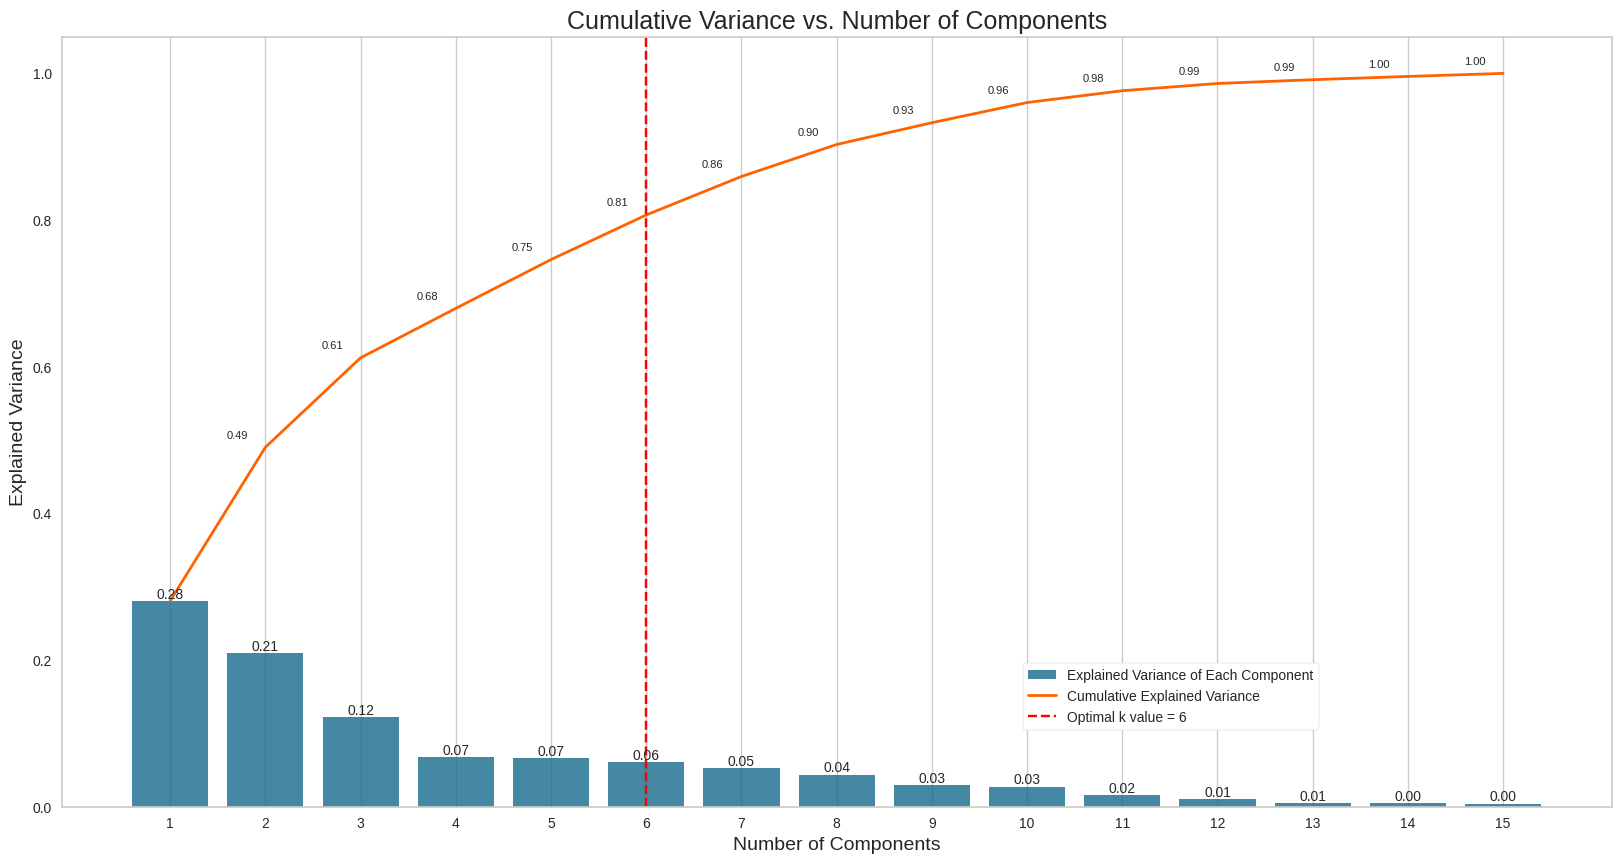

In [66]:
# Setting CustomerID as the index column
customer_data_scaled.set_index('CustomerID', inplace=True)
pca = PCA().fit(customer_data_scaled)
explained_variance_ratio = pca.explained_variance_ratio_
# Calculate the Cumulative Sum of the Explained Variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)
optimal_k = 6
plt.figure(figsize=(20, 10))
# Bar chart for the explained variance of each component
barplot = sns.barplot(x=list(range(1, len(cumulative_explained_variance) + 1)),
                      y=explained_variance_ratio,
                      alpha=0.8)
lineplot, = plt.plot(range(0, len(cumulative_explained_variance)), cumulative_explained_variance,
                     marker='x', linestyle='-', color='#ff6200', linewidth=2)
# Plot optimal k value line
optimal_k_line = plt.axvline(optimal_k - 1, color='red', linestyle='--',  label=f'Optimal k value = {optimal_k}')
# Set labels and title
plt.xlabel('Number of Components', fontsize=14)
plt.ylabel('Explained Variance', fontsize=14)
plt.title('Cumulative Variance vs. Number of Components', fontsize=18)
plt.xticks(range(0, len(cumulative_explained_variance)))
plt.legend(handles=[barplot.patches[0], lineplot, optimal_k_line],
           labels=['Explained Variance of Each Component', 'Cumulative Explained Variance', f'Optimal k value = {optimal_k}'],
           loc=(0.62, 0.1),
           frameon=True,
           framealpha=1.0,)
# Display the variance values for both graphs on the plots
x_offset = -0.3
y_offset = 0.01
for i, (ev_ratio, cum_ev_ratio) in enumerate(zip(explained_variance_ratio, cumulative_explained_variance)):
    plt.text(i, ev_ratio, f"{ev_ratio:.2f}", ha="center", va="bottom", fontsize=10)
    if i > 0:
        plt.text(i + x_offset, cum_ev_ratio + y_offset, f"{cum_ev_ratio:.2f}", ha="center", va="bottom", fontsize=8)

plt.grid(axis='both')
plt.show()

In [67]:
# Creating a PCA object with 6 components
pca = PCA(n_components=6)

# Fitting and transforming the original data to the new PCA dataframe
customer_data_pca = pca.fit_transform(customer_data_scaled)

# Creating a new dataframe from the PCA dataframe, with columns labeled PC1, PC2, etc.
customer_data_pca = pd.DataFrame(customer_data_pca, columns=['PC'+str(i+1) for i in range(pca.n_components_)])

# Adding the CustomerID index back to the new PCA dataframe
customer_data_pca.index = customer_data_scaled.index
customer_data_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6
CustomerID,,,,,,
12346.0,-2.259249,-1.584437,-1.650012,-0.442340,-0.843731,-1.729572
12347.0,3.221239,-1.555955,1.976867,0.673964,0.453178,0.916351
12348.0,0.627530,0.543075,0.705431,0.603470,-0.147453,2.412141
12350.0,-2.009166,-0.467780,0.540921,0.643815,-1.389917,0.125938
12352.0,0.352921,-1.494225,-0.750970,0.650788,0.002841,0.692686


In [69]:
# Define a function to highlight the top 3 absolute values in each column of a dataframe
def highlight_top3(column):
    top3 = column.abs().nlargest(3).index
    return ['background-color:  #FFB900' if i in top3 else '' for i in column.index]

# Create the PCA component DataFrame and apply the highlighting function
pc_df = pd.DataFrame(pca.components_.T, columns=['PC{}'.format(i+1) for i in range(pca.n_components_)],
                     index=customer_data_scaled.columns)

pc_df.style.apply(highlight_top3, axis=0)

,PC1,PC2,PC3,PC4,PC5,PC6
day_since_last_purchase,-0.217184,-0.003337,0.059943,-0.068731,-0.354601,-0.384651
Total_Transactions,0.382698,0.002534,-0.250350,0.127326,0.063232,-0.025883
Total_Products_Purchased,0.402143,-0.008147,0.073602,0.089143,0.118141,-0.004593
total_spend,0.430205,-0.006789,0.066773,0.068387,0.070374,-0.034654
Average_Transaction_Value,0.167106,-0.030205,0.597547,-0.109479,-0.053307,-0.097805
Unique_Products_Purchased,0.329631,0.048092,0.016902,0.271748,-0.033303,0.140074
Day_Of_Week,0.012406,0.995078,0.009479,-0.053816,0.037449,-0.057809
Hour,-0.016268,0.057524,0.000790,0.418988,-0.342903,0.673765
Average_Days_Between_Purchases,-0.022366,-0.037912,-0.115365,-0.289819,0.709982,0.207939
Is_UK,0.000855,0.007511,-0.014869,0.012096,0.002531,0.014586


In [70]:
def silhouette_analysis(df, start_k, stop_k, figsize=(15, 16)):
    """
    Perform Silhouette analysis for a range of k values and visualize the results.
    """

    # Set the size of the figure
    plt.figure(figsize=figsize)

    # Create a grid with (stop_k - start_k + 1) rows and 2 columns
    grid = gridspec.GridSpec(stop_k - start_k + 1, 2)

    # Assign the first plot to the first row and both columns
    first_plot = plt.subplot(grid[0, :])

    # First plot: Silhouette scores for different k values
    sns.set_palette(['darkorange'])

    silhouette_scores = []

    # Iterate through the range of k values
    for k in range(start_k, stop_k + 1):
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=100, random_state=0)
        km.fit(df)
        labels = km.predict(df)
        score = silhouette_score(df, labels)
        silhouette_scores.append(score)

    best_k = start_k + silhouette_scores.index(max(silhouette_scores))

    plt.plot(range(start_k, stop_k + 1), silhouette_scores, marker='o')
    plt.xticks(range(start_k, stop_k + 1))
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette score')
    plt.title('Average Silhouette Score for Different k Values', fontsize=15)

    # Add the optimal k value text to the plot
    optimal_k_text = f'The k value with the highest Silhouette score is: {best_k}'
    plt.text(10, 0.23, optimal_k_text, fontsize=12, verticalalignment='bottom',
             horizontalalignment='left', bbox=dict(facecolor='#fcc36d', edgecolor='#ff6200', boxstyle='round, pad=0.5'))


    # Second plot (subplot): Silhouette plots for each k value
    colors = sns.color_palette("bright")

    for i in range(start_k, stop_k + 1):
        km = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=100, random_state=0)
        row_idx, col_idx = divmod(i - start_k, 2)

        # Assign the plots to the second, third, and fourth rows
        ax = plt.subplot(grid[row_idx + 1, col_idx])

        visualizer = SilhouetteVisualizer(km, colors=colors, ax=ax)
        visualizer.fit(df)

        # Add the Silhouette score text to the plot
        score = silhouette_score(df, km.labels_)
        ax.text(0.97, 0.02, f'Silhouette Score: {score:.2f}', fontsize=12, \
                ha='right', transform=ax.transAxes, color='red')

        ax.set_title(f'Silhouette Plot for {i} Clusters', fontsize=15)

    plt.tight_layout()
    plt.show()


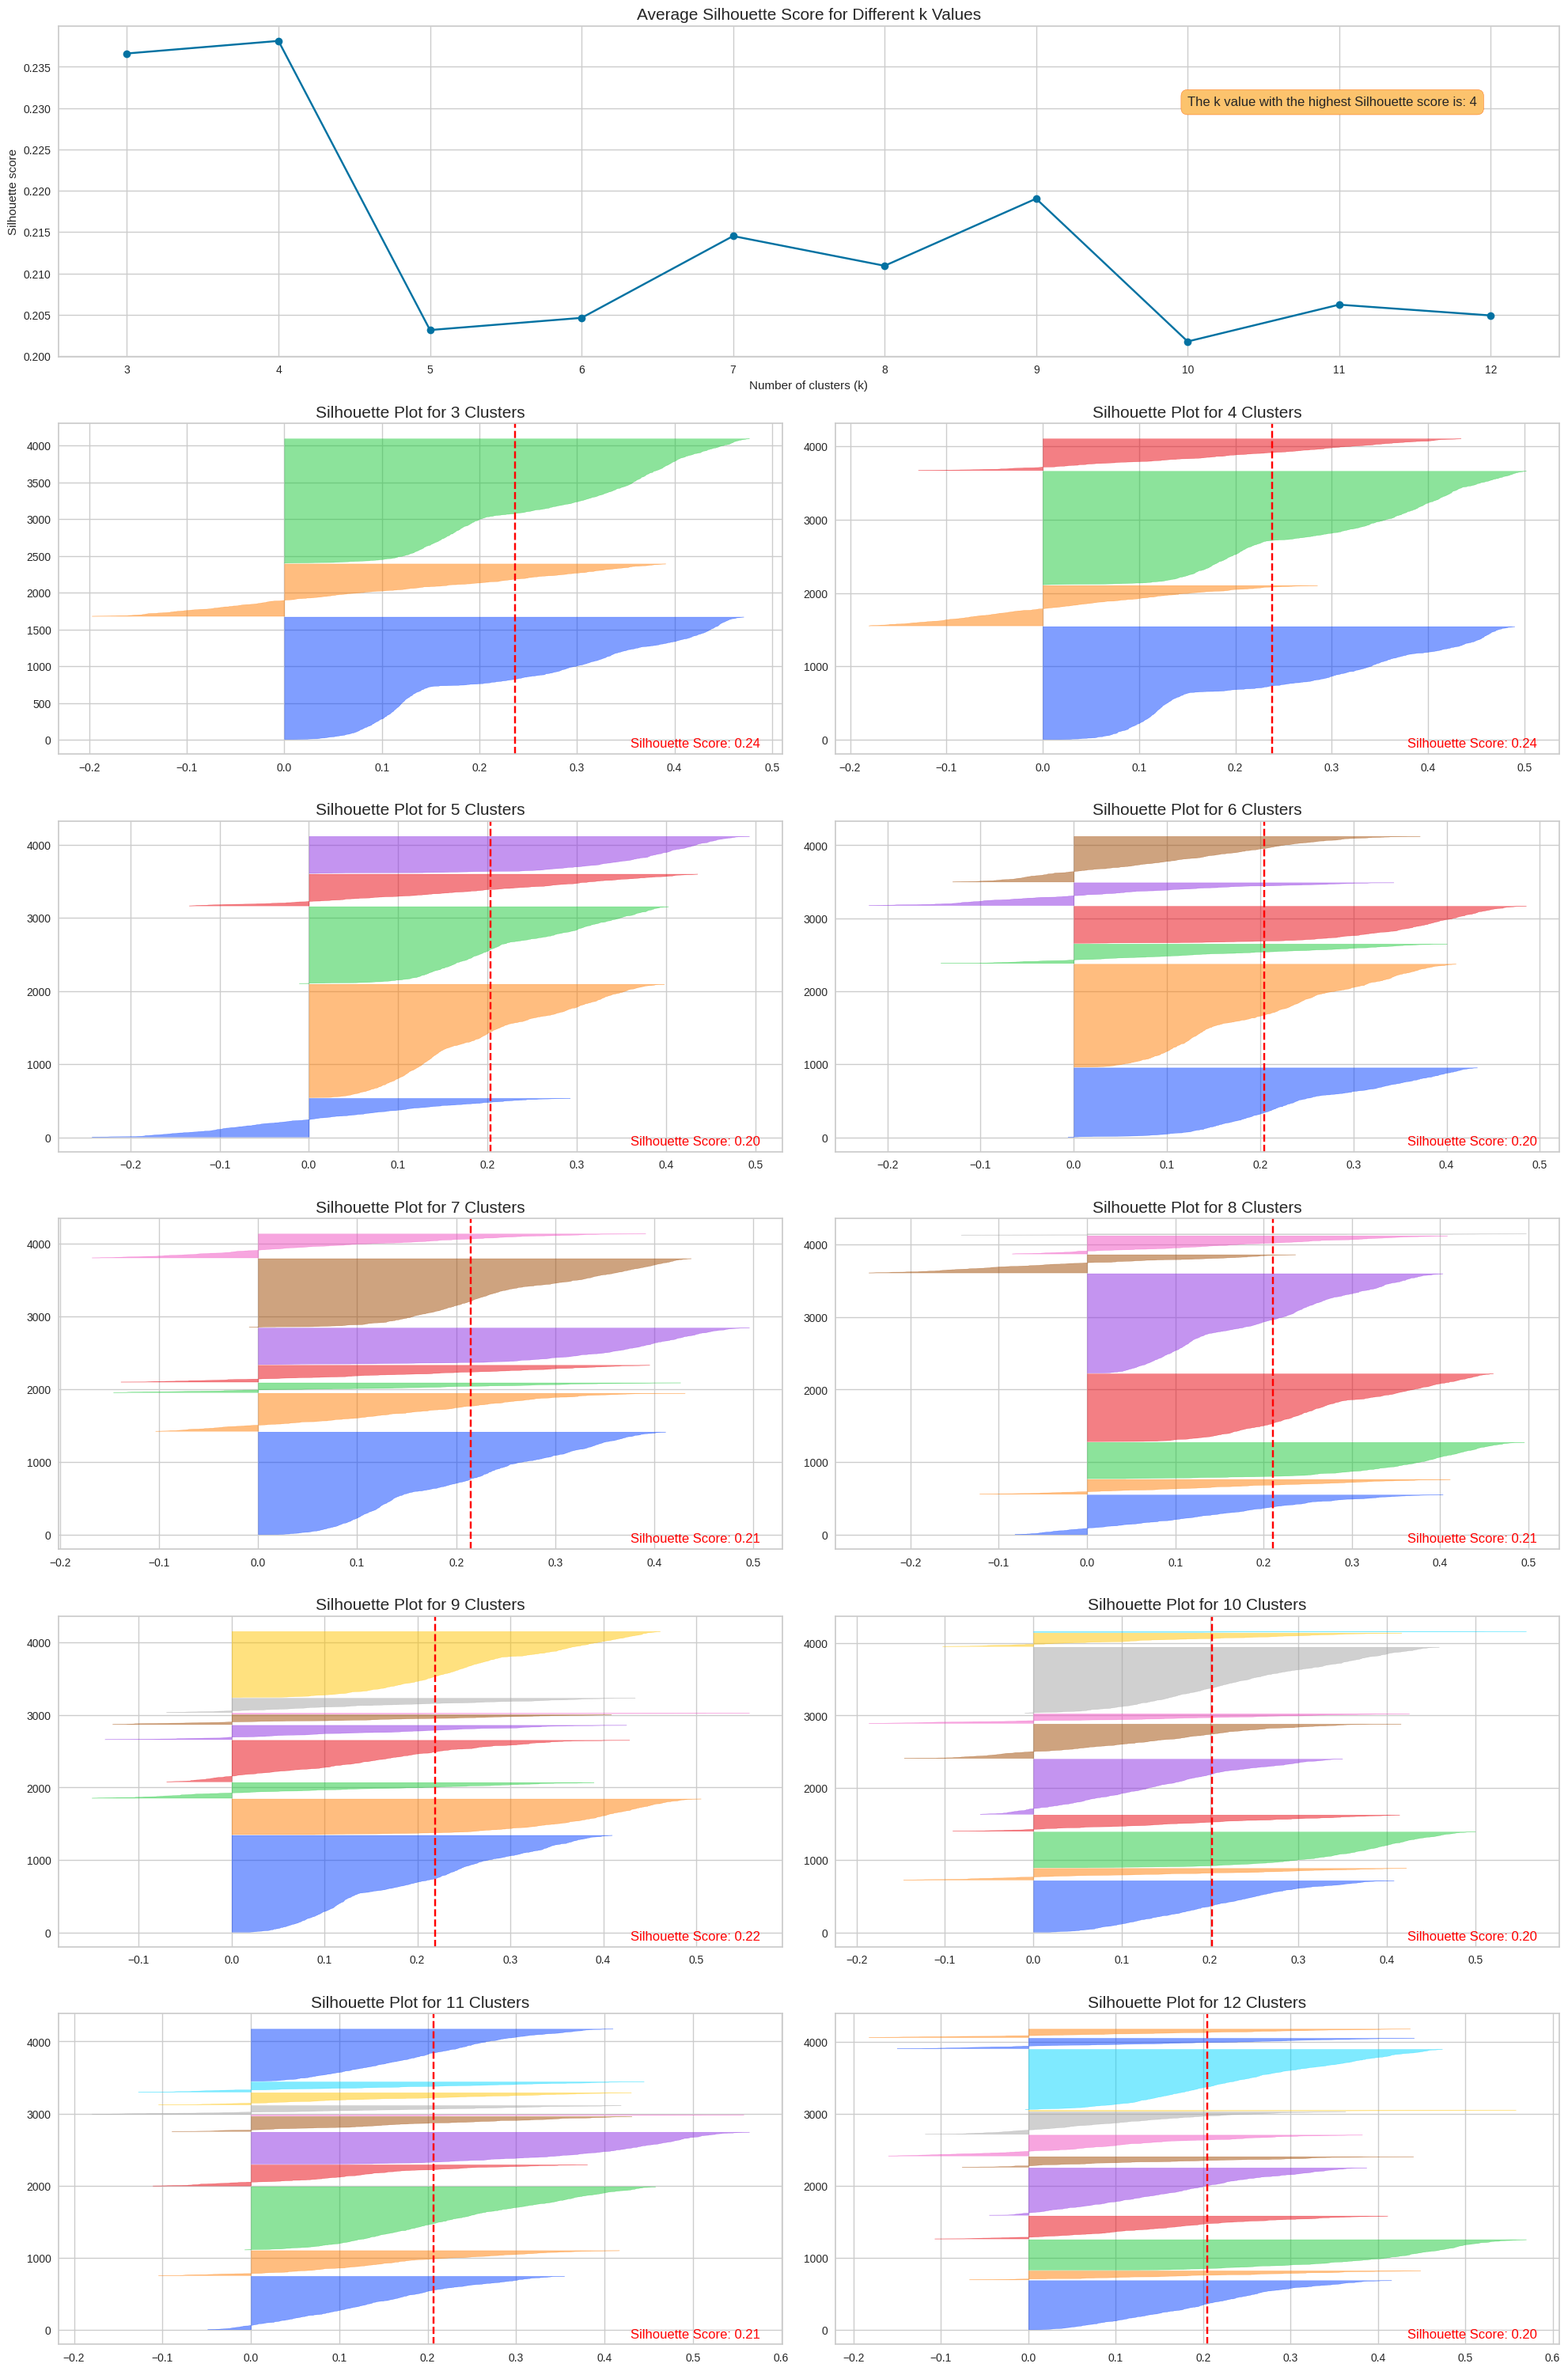

In [71]:
silhouette_analysis(customer_data_pca, 3, 12, figsize=(20, 50))

In [72]:
# Apply KMeans clustering using the optimal k
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=100, random_state=0)
kmeans.fit(customer_data_pca)

# Get the frequency of each cluster
cluster_frequencies = Counter(kmeans.labels_)

# Create a mapping from old labels to new labels based on frequency
label_mapping = {label: new_label for new_label, (label, _) in
                 enumerate(cluster_frequencies.most_common())}

In [73]:
label_mapping = {v: k for k, v in {2: 1, 1: 0, 0: 2}.items()}
# Apply the mapping to get the new labels
new_labels = np.array([label_mapping[label] for label in kmeans.labels_])

# Append the new cluster labels back to the original dataset
customer_data_cleaned['cluster'] = new_labels

# Append the new cluster labels to the PCA version of the dataset
customer_data_pca['cluster'] = new_labels

In [74]:
customer_data_cleaned.head()

,CustomerID,day_since_last_purchase,Total_Transactions,Total_Products_Purchased,total_spend,Average_Transaction_Value,Unique_Products_Purchased,Day_Of_Week,Hour,Average_Days_Between_Purchases,Is_UK,Cancellation_Frequency,Cancellation_Rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,cluster
0,12346.0,325,2,0,0.0,0.0,1,1,10,0.0,1,1,0.5,0.0,0.0,0.0,0
1,12347.0,2,7,2458,4310.0,615.714286,103,1,14,2.016575,0,0,0.0,615.714286,341.070789,4.486071,2
2,12348.0,75,4,2332,1437.24,359.31,21,3,19,10.884615,0,0,0.0,359.31,203.875689,-100.884,1
3,12350.0,310,1,196,294.4,294.4,16,2,16,0.0,0,0,0.0,294.4,0.0,0.0,0
4,12352.0,36,8,463,1265.41,158.17625,57,1,14,3.13253,0,1,0.125,316.3525,134.700629,9.351,0


In [75]:
customer_data_cleaned.to_csv('customer_data_cleaned.csv', index=False)

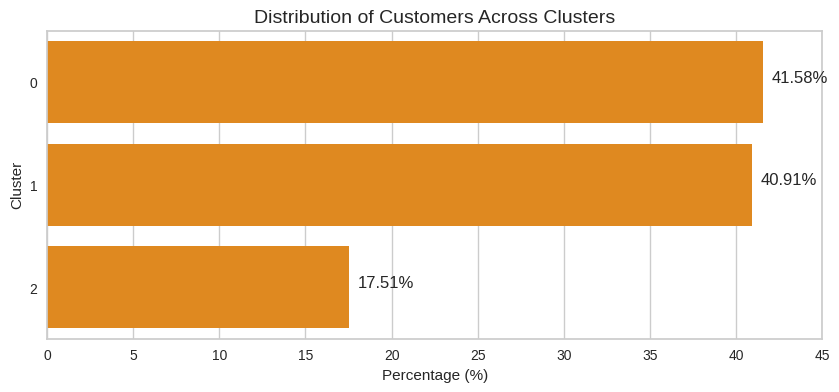

In [78]:
# Calculate the percentage of customers in each cluster
cluster_percentage = (customer_data_pca['cluster'].value_counts(normalize=True) * 100).reset_index()
cluster_percentage.columns = ['Cluster', 'Percentage']
cluster_percentage.sort_values(by='Cluster', inplace=True)


# Create a horizontal bar plot
plt.figure(figsize=(10, 4))
sns.barplot(x='Percentage', y='Cluster', data=cluster_percentage, orient='h',)

# Adding percentages on the bars
for index, value in enumerate(cluster_percentage['Percentage']):
    plt.text(value+0.5, index, f'{value:.2f}%')

plt.title('Distribution of Customers Across Clusters', fontsize=14)
plt.xticks(ticks=np.arange(0, 50, 5))
plt.xlabel('Percentage (%)')

# Show the plot
plt.show()

In [81]:
colors = ['#e8000b', '#1ac938', '#023eff']


In [82]:
# Setting 'CustomerID' column as index and assigning it to a new dataframe
df_customer = customer_data_cleaned.set_index('CustomerID')

# Standardize the data (excluding the cluster column)
scaler = StandardScaler()
df_customer_standardized = scaler.fit_transform(df_customer.drop(columns=['cluster'], axis=1))

# Create a new dataframe with standardized values and add the cluster column back
df_customer_standardized = pd.DataFrame(df_customer_standardized, columns=df_customer.columns[:-1], index=df_customer.index)
df_customer_standardized['cluster'] = df_customer['cluster']

# Calculate the centroids of each cluster
cluster_centroids = df_customer_standardized.groupby('cluster').mean()

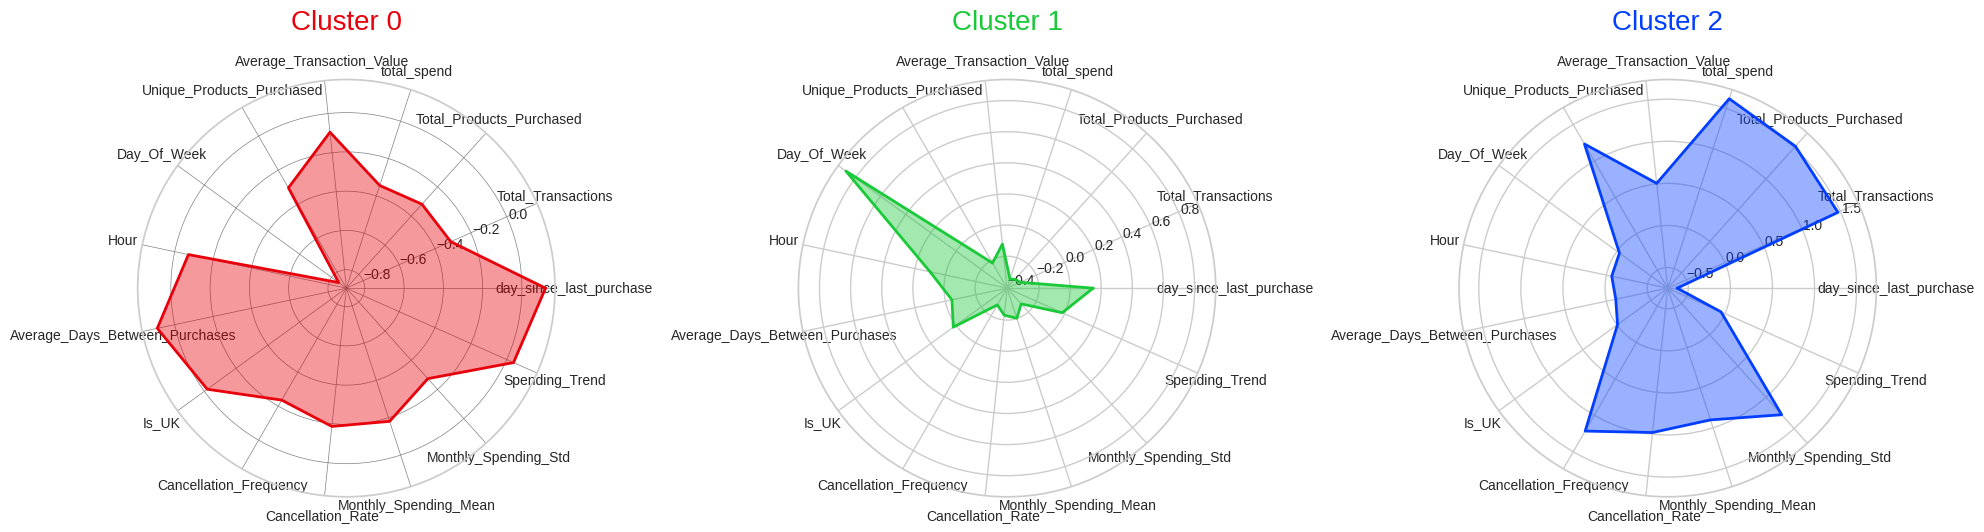

In [83]:
# Function to create a radar chart
def create_radar_chart(ax, angles, data, color, cluster):
    # Plot the data and fill the area
    ax.fill(angles, data, color=color, alpha=0.4)
    ax.plot(angles, data, color=color, linewidth=2, linestyle='solid')

    # Add a title
    ax.set_title(f'Cluster {cluster}', size=20, color=color, y=1.1)

# Set data
labels=np.array(cluster_centroids.columns)
num_vars = len(labels)

# Compute angle of each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# The plot is circular, so we need to "complete the loop" and append the start to the end
labels = np.concatenate((labels, [labels[0]]))
angles += angles[:1]

# Initialize the figure
fig, ax = plt.subplots(figsize=(20, 10), subplot_kw=dict(polar=True), nrows=1, ncols=3)

# Create radar chart for each cluster
for i, color in enumerate(colors):
    data = cluster_centroids.loc[i].tolist()
    data += data[:1]  # Complete the loop
    create_radar_chart(ax[i], angles, data, color, i)

# Add input data
ax[0].set_xticks(angles[:-1])
ax[0].set_xticklabels(labels[:-1])

ax[1].set_xticks(angles[:-1])
ax[1].set_xticklabels(labels[:-1])

ax[2].set_xticks(angles[:-1])
ax[2].set_xticklabels(labels[:-1])

# Add a grid
ax[0].grid(color='grey', linewidth=0.5)

# Display the plot
plt.tight_layout()
plt.show()

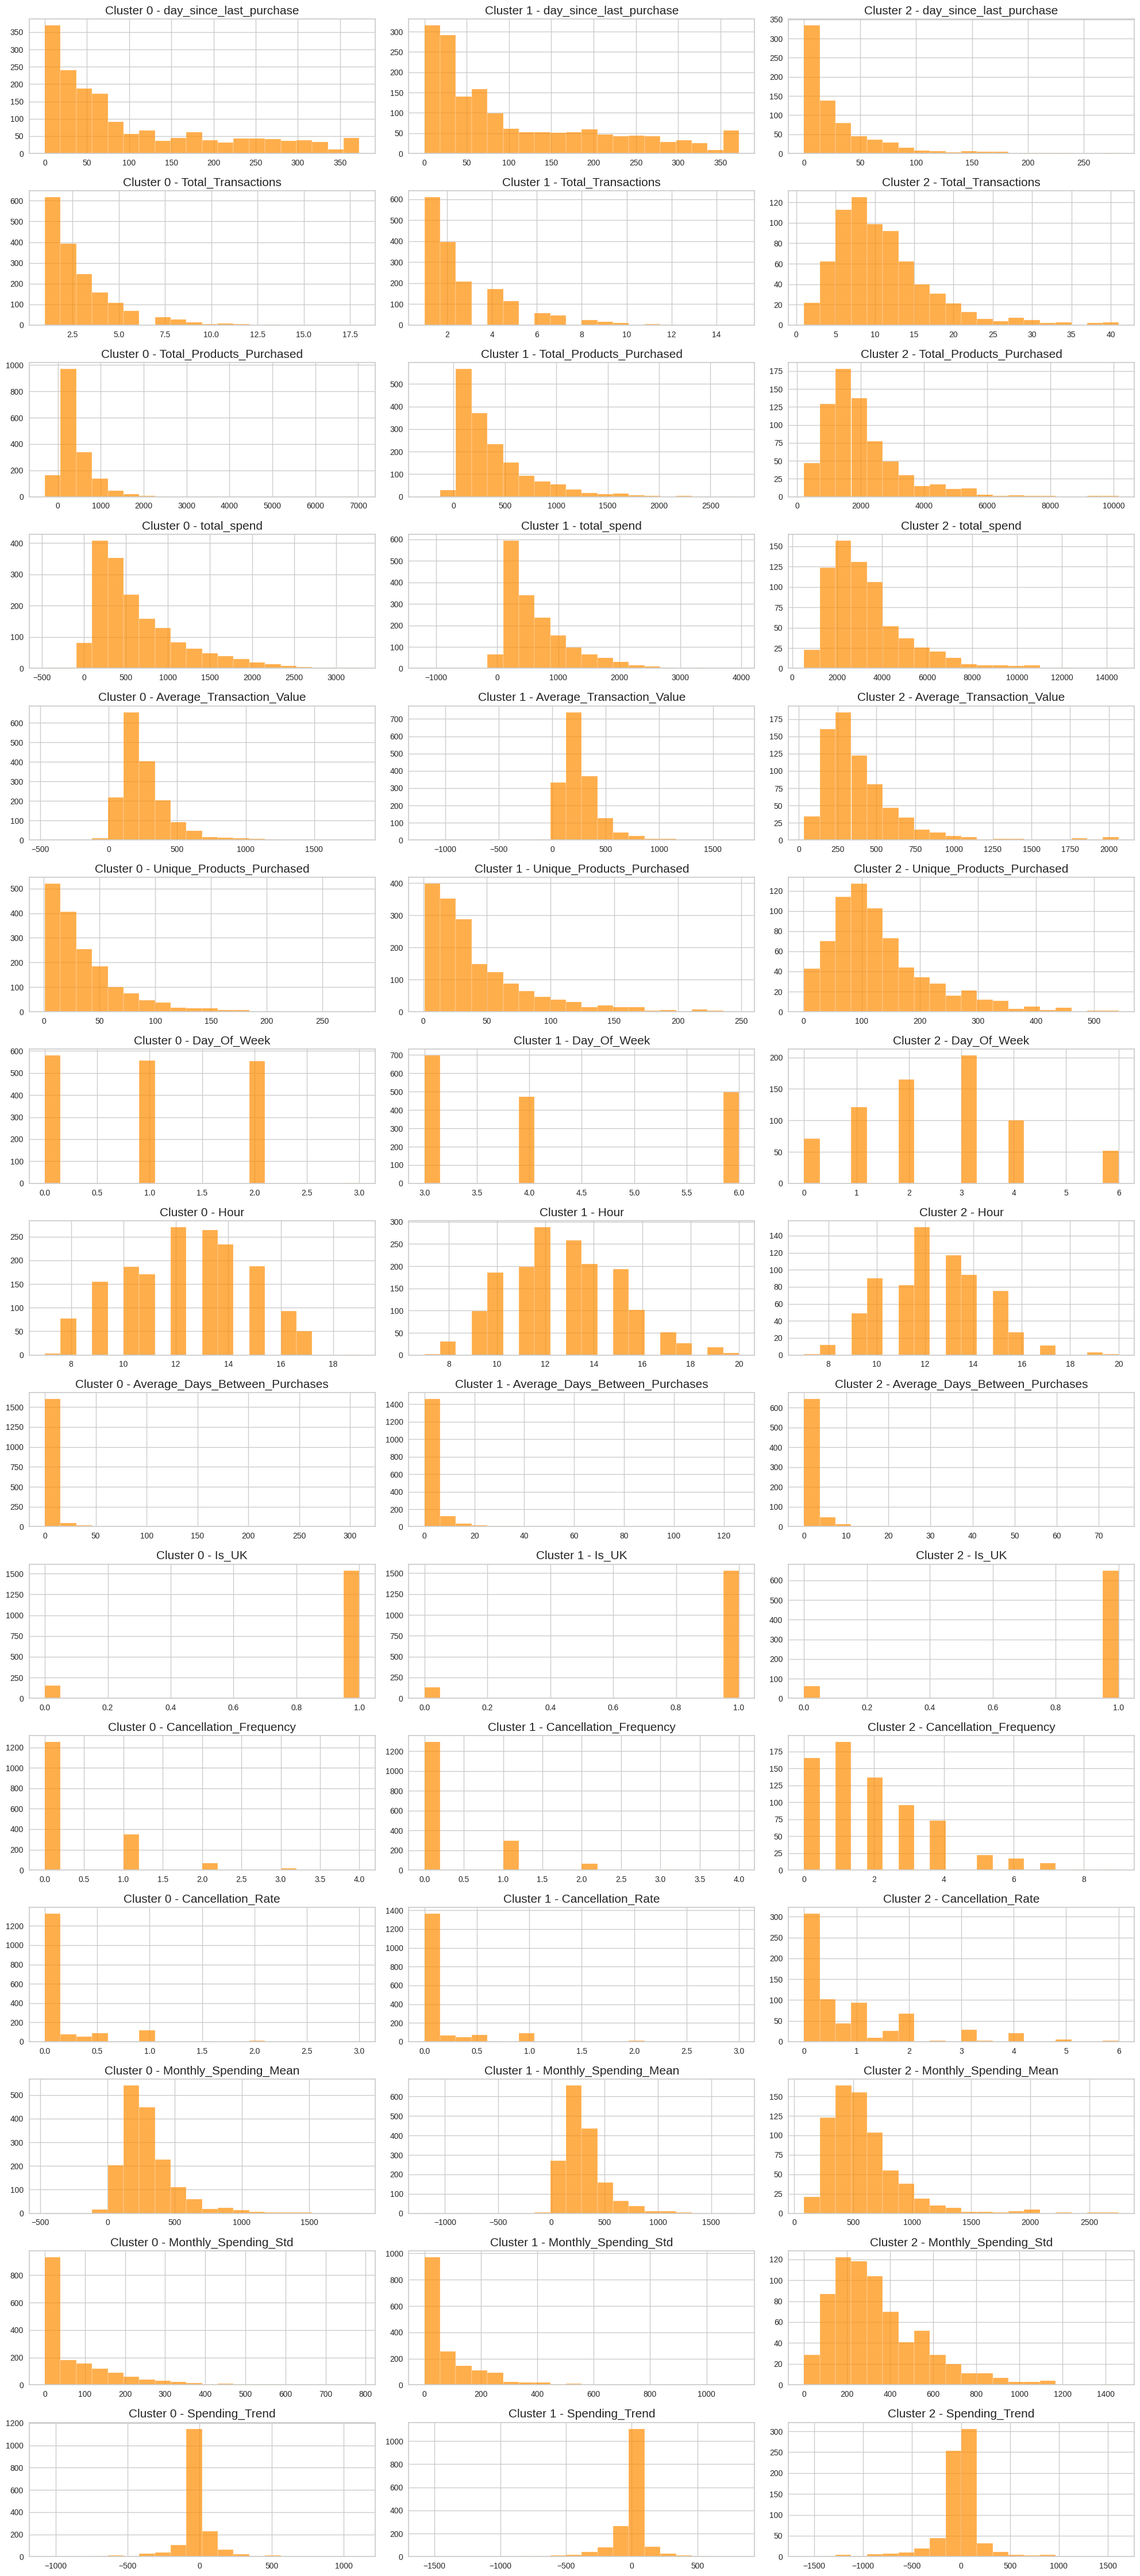

In [84]:
# Plot histograms for each feature segmented by the clusters
features = customer_data_cleaned.columns[1:-1]
clusters = customer_data_cleaned['cluster'].unique()
clusters.sort()

# Setting up the subplots
n_rows = len(features)
n_cols = len(clusters)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3*n_rows))

# Plotting histograms
for i, feature in enumerate(features):
    for j, cluster in enumerate(clusters):
        data = customer_data_cleaned[customer_data_cleaned['cluster'] == cluster][feature]
        axes[i, j].hist(data, bins=20, edgecolor='w', alpha=0.7)
        axes[i, j].set_title(f'Cluster {cluster} - {feature}', fontsize=15)
        axes[i, j].set_xlabel('')
        axes[i, j].set_ylabel('')

# Adjusting layout to prevent overlapping
plt.tight_layout()
plt.show()

**recommendation system**

In [85]:
# Step 1: Extract the CustomerIDs of the outliers and remove their transactions from the main dataframe
outlier_customer_ids = outliers_data['CustomerID'].astype('float').unique()
df_filtered = df[~df['CustomerID'].isin(outlier_customer_ids)]

# Step 2: Ensure consistent data type for CustomerID across both dataframes before merging
customer_data_cleaned['CustomerID'] = customer_data_cleaned['CustomerID'].astype('float')

# Step 3: Merge the transaction data with the customer data to get the cluster information for each transaction
merged_data = df_filtered.merge(customer_data_cleaned[['CustomerID', 'cluster']], on='CustomerID', how='inner')

# Step 4: Identify the top 10 best-selling products in each cluster based on the total quantity sold
best_selling_products = merged_data.groupby(['cluster', 'StockCode', 'Description'])['Quantity'].sum().reset_index()
best_selling_products = best_selling_products.sort_values(by=['cluster', 'Quantity'], ascending=[True, False])
top_products_per_cluster = best_selling_products.groupby('cluster').head(10)

# Step 5: Create a record of products purchased by each customer in each cluster
customer_purchases = merged_data.groupby(['CustomerID', 'cluster', 'StockCode'])['Quantity'].sum().reset_index()

# Step 6: Generate recommendations for each customer in each cluster
recommendations = []
for cluster in top_products_per_cluster['cluster'].unique():
    top_products = top_products_per_cluster[top_products_per_cluster['cluster'] == cluster]
    customers_in_cluster = customer_data_cleaned[customer_data_cleaned['cluster'] == cluster]['CustomerID']

    for customer in customers_in_cluster:
        # Identify products already purchased by the customer
        customer_purchased_products = customer_purchases[(customer_purchases['CustomerID'] == customer) &
                                                         (customer_purchases['cluster'] == cluster)]['StockCode'].tolist()

        # Find top 3 products in the best-selling list that the customer hasn't purchased yet
        top_products_not_purchased = top_products[~top_products['StockCode'].isin(customer_purchased_products)]
        top_3_products_not_purchased = top_products_not_purchased.head(3)

        # Append the recommendations to the list
        recommendations.append([customer, cluster] + top_3_products_not_purchased[['StockCode', 'Description']].values.flatten().tolist())

# Step 7: Create a dataframe from the recommendations list and merge it with the original customer data
recommendations_df = pd.DataFrame(recommendations, columns=['CustomerID', 'cluster', 'Rec1_StockCode', 'Rec1_Description', \
                                                 'Rec2_StockCode', 'Rec2_Description', 'Rec3_StockCode', 'Rec3_Description'])
customer_data_with_recommendations = customer_data_cleaned.merge(recommendations_df, on=['CustomerID', 'cluster'], how='right')

In [86]:
# Display 10 random rows from the customer_data_with_recommendations dataframe
customer_data_with_recommendations.set_index('CustomerID').iloc[:, -6:].sample(10, random_state=0)

,Rec1_StockCode,Rec1_Description,Rec2_StockCode,Rec2_Description,Rec3_StockCode,Rec3_Description
CustomerID,,,,,,
15857.0,18007,ESSENTIAL BALM 3.5G TIN IN ENVELOPE,84879,ASSORTED COLOUR BIRD ORNAMENT,17003,BROCADE RING PURSE
15847.0,18007,ESSENTIAL BALM 3.5G TIN IN ENVELOPE,17003,BROCADE RING PURSE,85123A,WHITE HANGING HEART T-LIGHT HOLDER
17301.0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,15036,ASSORTED COLOURS SILK FAN,85123A,WHITE HANGING HEART T-LIGHT HOLDER
17267.0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,15036,ASSORTED COLOURS SILK FAN,85123A,WHITE HANGING HEART T-LIGHT HOLDER
15054.0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,84879,ASSORTED COLOUR BIRD ORNAMENT,15036,ASSORTED COLOURS SILK FAN
14377.0,18007,ESSENTIAL BALM 3.5G TIN IN ENVELOPE,84879,ASSORTED COLOUR BIRD ORNAMENT,17003,BROCADE RING PURSE
15270.0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,85099B,JUMBO BAG RED RETROSPOT,84879,ASSORTED COLOUR BIRD ORNAMENT
17551.0,18007,ESSENTIAL BALM 3.5G TIN IN ENVELOPE,84879,ASSORTED COLOUR BIRD ORNAMENT,17003,BROCADE RING PURSE
17813.0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,85099B,JUMBO BAG RED RETROSPOT,16014,SMALL CHINESE STYLE SCISSOR
